# Quantum Face Recognition using MG-QCNN

This project implements a hybrid classical-quantum model using PennyLane and PyTorch for face recognition. 
The model uses quantum circuits combined with classical deep learning techniques to classify facial images.

In [1]:
!pip install pennylane torch torchvision opencv-python scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 42.5 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
from sklearn.model_selection import train_test_split

In [5]:
images=[]
labels=[]

dataset_path="/content/data"

for file in os.listdir(dataset_path):

    if not file.startswith("subject"):
        continue

    label=int(file.split(".")[0].replace("subject",""))-1

    img_path=os.path.join(dataset_path,file)

    img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img = cv2.resize(img,(20,20))

    img=img/255.0
    img=(img-0.5)*2
    img=img*np.pi

    images.append(img)
    labels.append(label)

X=np.array(images)
y=np.array(labels)

print("Total Images:",len(X))
print("Classes:",len(set(y)))

Total Images: 165
Classes: 15


In [6]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:",len(X_train))
print("Test:",len(X_test))

Train: 132
Test: 33


In [7]:
n_qubits=4
dev=qml.device("default.qubit",wires=n_qubits)

In [8]:
@qml.qnode(dev,interface="torch")

def quantum_circuit(inputs,weights):

    for i in range(4):
        qml.RY(inputs[i],wires=i)

    for i in range(4):
        qml.RX(weights[2*i],wires=i)
        qml.RZ(weights[2*i+1],wires=i)

    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])
    qml.CNOT(wires=[3,0])

    qml.CNOT(wires=[0,2])
    qml.CNOT(wires=[1,3])

    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

(<Figure size 1200x500 with 1 Axes>, <Axes: >)

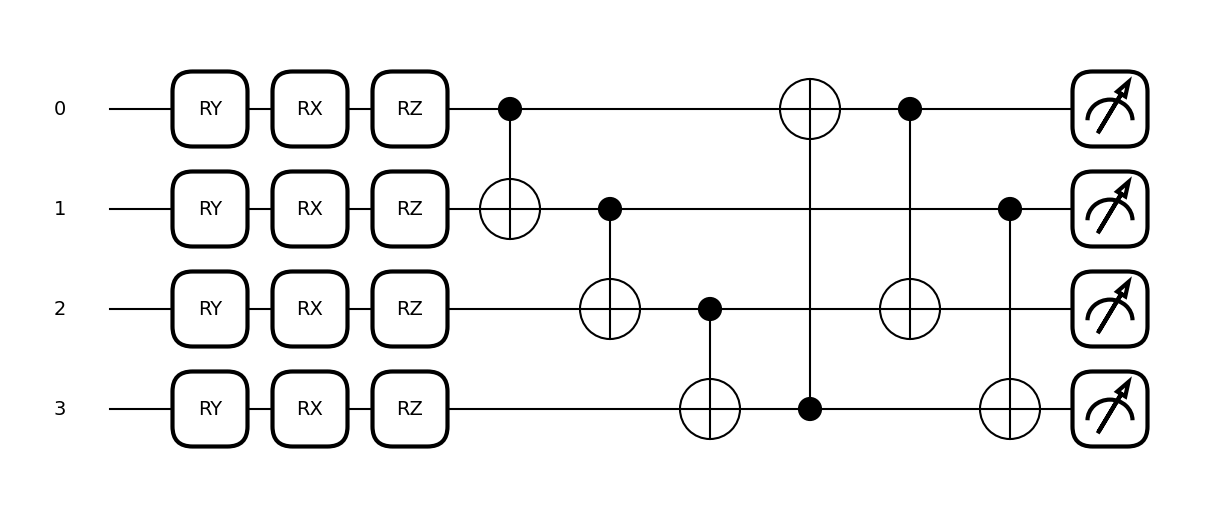

In [9]:
qml.draw_mpl(quantum_circuit)(
    torch.tensor([0.1,0.2,0.3,0.4]),
    torch.randn(8)
)

In [10]:
class QuantumConv(nn.Module):

    def __init__(self):
        super().__init__()
        self.q_weights=nn.Parameter(0.01*torch.randn(8))

    def forward(self,x):

        outputs=[]

        for i in range(0,19,2):
          for j in range(0,19,2):

                patch=torch.stack([
                    x[i][j],
                    x[i][j+1],
                    x[i+1][j],
                    x[i+1][j+1]
                ]).float()

                q_out=quantum_circuit(patch,self.q_weights)

                outputs.append(torch.stack(q_out))

        return torch.stack(outputs)

In [11]:
class MGQCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.qconv = QuantumConv()

        self.fc1 = nn.Linear(400,128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128,15)

    def forward(self,x):

        x = self.qconv(x)

        x = x.view(-1).float()

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [12]:
model=MGQCNN()

In [13]:
criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(model.parameters(),lr=0.0005)

1 and half hr

In [14]:
epochs=45

for epoch in range(epochs):

    total_loss=0

    for i in range(len(X_train)):

        x=torch.tensor(X_train[i])
        y_true=torch.tensor(y_train[i])

        optimizer.zero_grad()

        output=model(x)

        loss=criterion(output.unsqueeze(0),y_true.unsqueeze(0))

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

    print("Epoch",epoch+1,"Loss:",total_loss)

Epoch 1 Loss: 350.5636793375015
Epoch 2 Loss: 288.07553148269653
Epoch 3 Loss: 214.7407756447792
Epoch 4 Loss: 166.78647504001856
Epoch 5 Loss: 123.36991199851036
Epoch 6 Loss: 95.95906010270119
Epoch 7 Loss: 75.96043927967548
Epoch 8 Loss: 63.1720503391698
Epoch 9 Loss: 51.760590767487884
Epoch 10 Loss: 37.86790124617983
Epoch 11 Loss: 31.439866988919675
Epoch 12 Loss: 23.85947549645789
Epoch 13 Loss: 18.26252576848492
Epoch 14 Loss: 20.19058789277915
Epoch 15 Loss: 12.404002056864556
Epoch 16 Loss: 13.727348808723036
Epoch 17 Loss: 10.618983335065423
Epoch 18 Loss: 10.662831563968211
Epoch 19 Loss: 10.179503685620148
Epoch 20 Loss: 7.439236106714816
Epoch 21 Loss: 7.106616557281541
Epoch 22 Loss: 5.3484364274809195
Epoch 23 Loss: 3.981971662178694
Epoch 24 Loss: 3.7844788159127347
Epoch 25 Loss: 4.555873360246551
Epoch 26 Loss: 3.1239821763083455
Epoch 27 Loss: 2.6528680124747552
Epoch 28 Loss: 5.243261817291568
Epoch 29 Loss: 3.0406824051497097
Epoch 30 Loss: 2.414148036484221
Epoch

In [15]:
correct=0

for i in range(len(X_test)):

    x=torch.tensor(X_test[i])

    output=model(x)

    pred=torch.argmax(output)

    if pred.item()==y_test[i]:
        correct+=1

accuracy=correct/len(X_test)

print("Model: MGQCNN")
print("Accuracy:",accuracy*100,"%")

Model: MGQCNN
Accuracy: 66.66666666666666 %
